# 🧪 PyTorch Lab 3.2: WGAN and WGAN-GP on MNIST

This lab implements two Wasserstein GAN variants on MNIST:

1. **Convolutional WGAN with weight clipping**
2. **Convolutional WGAN-GP with gradient penalty**

Compared with a fully connected implementation, the convolutional version is much more appropriate for images because it exploits spatial locality and local stroke patterns.

**Dataset:** MNIST  
**Main concepts:** GAN, Wasserstein distance, critic, 1-Lipschitz constraint, weight clipping, gradient penalty  
**Recommended duration:** 3 hours


## 1. From GANs to WGANs

### 1.1 Classical GAN reminder

A classical GAN contains two neural networks:

- a **generator** $G$, which maps random noise $z \sim p(z)$ to a generated image $G(z)$;
- a **discriminator** $D$, which tries to distinguish real images from generated images.

The minimax objective is:

$$
\min_G \max_D 
\mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)]
+
\mathbb{E}_{z \sim p(z)}[\log(1-D(G(z)))].
$$

Classical GANs can be difficult to train because:

- gradients may vanish when the discriminator becomes too strong;
- the Jensen-Shannon divergence can be uninformative when the real and generated distributions have little overlap;
- mode collapse may occur;
- losses are often difficult to interpret.


### 1.2 Wasserstein distance and WGAN

WGAN replaces the classical GAN objective with an approximation of the **Wasserstein-1 distance**, also called **Earth Mover's Distance**.

Intuitively, it measures the minimum cost of transporting probability mass from the generated distribution to the real data distribution.

Using the Kantorovich-Rubinstein dual form:

$$
W(p_{\text{data}}, p_G)
=
\sup_{\|f\|_L \le 1}
\mathbb{E}_{x \sim p_{\text{data}}}[f(x)]
-
\mathbb{E}_{z \sim p(z)}[f(G(z))].
$$

In WGAN:

- the discriminator is replaced by a **critic** $C$;
- the critic outputs a real-valued score, not a probability;
- the critic has **no sigmoid** at the output;
- the critic must be approximately **1-Lipschitz**.

The original WGAN enforces this constraint using **weight clipping**. WGAN-GP replaces clipping with a **gradient penalty**, which is usually more stable.


In [36]:
import os
import math
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Subset


In [37]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


Device: cuda


## 2. Load MNIST

The generator ends with `tanh`, so generated images are in $[-1,1]$.

Therefore, MNIST images are normalized from $[0,1]$ to $[-1,1]$:

$$
x_{\text{norm}} = \frac{x - 0.5}{0.5}.
$$

For local execution, the default configuration uses a subset of MNIST. On a GPU, set `MAX_TRAIN_SAMPLES = None`.


In [38]:
BATCH_SIZE = 64
MAX_TRAIN_SAMPLES = 20000  # Set to None to use the full MNIST training set.

# num_workers=0 is the safest default for local Jupyter notebooks,
# especially on Windows. Increase it on Linux/macOS if desired.
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

if MAX_TRAIN_SAMPLES is not None:
    indices = list(range(min(MAX_TRAIN_SAMPLES, len(train_dataset))))
    train_dataset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 20000
Test samples: 10000


Batch shape: torch.Size([64, 1, 28, 28])
Min value: -1.0 Max value: 1.0


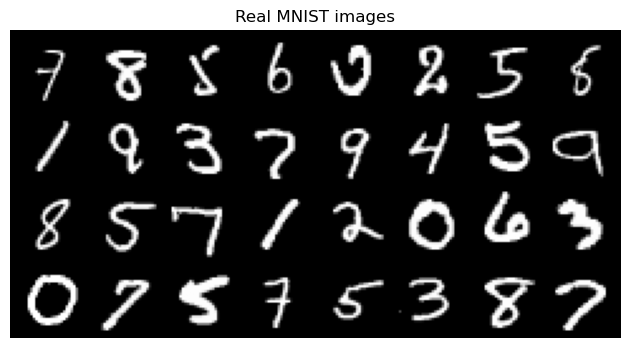

In [39]:
def denormalize(x):
    """Convert images from [-1, 1] back to [0, 1] for visualization."""
    return ((x + 1) / 2).clamp(0, 1)


def show_images(images, title=None, nrow=8, figsize=(8, 4)):
    images = images.detach().cpu()
    grid = make_grid(denormalize(images), nrow=nrow, padding=2)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()


real_batch, real_labels = next(iter(train_loader))
print("Batch shape:", real_batch.shape)
print("Min value:", real_batch.min().item(), "Max value:", real_batch.max().item())
show_images(real_batch[:32], title="Real MNIST images")


## 3. Convolutional Generator and Critic

The previous MLP version is too weak for image generation: it does not exploit local spatial structure. Here we use a DCGAN-style architecture.

### Generator

The generator maps:

$$
z \in \mathbb{R}^{d_z} \rightarrow \hat{x} \in \mathbb{R}^{1 \times 28 \times 28}.
$$

It first projects the latent vector to a low-resolution feature map, then upsamples it with transposed convolutions.

### Critic

The critic maps:

$$
x \in \mathbb{R}^{1 \times 28 \times 28} \rightarrow C(x) \in \mathbb{R}.
$$

Important rules:

- no sigmoid at the output;
- no binary cross entropy;
- for WGAN-GP, avoid `BatchNorm` inside the critic because the gradient penalty is computed per sample;
- the generator can use `BatchNorm`.


In [40]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim

        self.project = nn.Sequential(
            nn.Linear(latent_dim, 256 * 7 * 7),
            nn.BatchNorm1d(256 * 7 * 7),
            nn.ReLU(inplace=True)
        )

        self.net = nn.Sequential(
            nn.Unflatten(1, (256, 7, 7)),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 14x14 -> 28x28
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.project(z)
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        # No BatchNorm here. This is important for WGAN-GP.
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),    # 28x28 -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14x14 -> 7x7
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [41]:
def initialize_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)
    elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.normal_(module.weight, mean=1.0, std=0.02)
        nn.init.constant_(module.bias, 0.0)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def set_requires_grad(model, flag):
    for p in model.parameters():
        p.requires_grad_(flag)


generator = Generator(LATENT_DIM).to(device)
critic = Critic().to(device)

generator.apply(initialize_weights)
critic.apply(initialize_weights)

print(generator)
print(critic)
print("Generator parameters:", count_parameters(generator))
print("Critic parameters:", count_parameters(critic))

z = torch.randn(8, LATENT_DIM, device=device)
fake = generator(z)
scores = critic(fake)

print("Generated batch shape:", fake.shape)
print("Critic score shape:", scores.shape)
print("Generated value range:", fake.min().item(), fake.max().item())
assert fake.shape == (8, 1, 28, 28)
assert scores.shape == (8,)


Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=12544, bias=True)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (net): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 7, 7))
    (1): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): Tanh()
  )
)
Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 

## 4. WGAN losses

The critic approximates:

$$
\mathbb{E}[C(x_{\text{real}})] - \mathbb{E}[C(x_{\text{fake}})].
$$

Because PyTorch optimizers minimize, we use:

$$
L_C =
\mathbb{E}[C(x_{\text{fake}})]
-
\mathbb{E}[C(x_{\text{real}})].
$$

The generator tries to maximize critic scores on fake images:

$$
L_G = - \mathbb{E}[C(x_{\text{fake}})].
$$


In [42]:
def critic_loss_wgan(real_scores, fake_scores):
    return fake_scores.mean() - real_scores.mean()


def generator_loss_wgan(fake_scores):
    return -fake_scores.mean()


## 5. Convolutional WGAN with weight clipping

The original WGAN enforces the 1-Lipschitz constraint by clipping all critic weights to a small interval:

$$
w \leftarrow \text{clip}(w, -c, c).
$$


Compared with the previous MLP version, this convolutional version should produce better samples. However, weight clipping is still a crude constraint, so WGAN-GP is usually more stable.

Important implementation choices:

- use `RMSprop` for the original WGAN;
- no `sigmoid`;
- no `BCELoss`;
- train the critic several times before one generator update;
- use `detach()` for fake images during critic training;
- no `detach()` during generator training.

The critic score gap

$$
\mathbb{E}[C(x_{\text{real}})] - \mathbb{E}[C(x_{\text{fake}})]
$$

is an empirical estimate of the Wasserstein distance, not an exact distance.


Epoch [5/200] C_loss: -4.3231 | G_loss: -229.2456 | W_est: 4.3231 | C(real): 234.0388 | C(fake): 229.7158
Epoch [10/200] C_loss: -1.2495 | G_loss: -137.4537 | W_est: 1.2495 | C(real): 139.0239 | C(fake): 137.7744
Epoch [15/200] C_loss: -1.9780 | G_loss: -100.2096 | W_est: 1.9780 | C(real): 102.2010 | C(fake): 100.2229
Epoch [20/200] C_loss: -2.5508 | G_loss: -87.8748 | W_est: 2.5508 | C(real): 90.6028 | C(fake): 88.0520


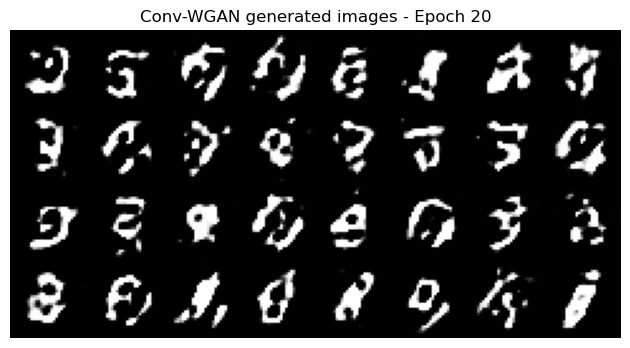

Epoch [25/200] C_loss: -3.3228 | G_loss: -67.8664 | W_est: 3.3228 | C(real): 71.2302 | C(fake): 67.9074
Epoch [30/200] C_loss: -3.9094 | G_loss: -63.5195 | W_est: 3.9094 | C(real): 67.5011 | C(fake): 63.5918
Epoch [35/200] C_loss: -3.9653 | G_loss: -79.7816 | W_est: 3.9653 | C(real): 83.8113 | C(fake): 79.8460
Epoch [40/200] C_loss: -3.3798 | G_loss: -94.6111 | W_est: 3.3798 | C(real): 97.9951 | C(fake): 94.6154


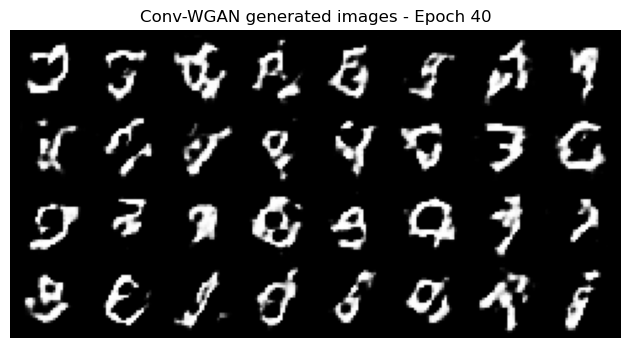

Epoch [45/200] C_loss: -2.7551 | G_loss: -94.5065 | W_est: 2.7551 | C(real): 97.4199 | C(fake): 94.6648
Epoch [50/200] C_loss: -2.3492 | G_loss: -95.9914 | W_est: 2.3492 | C(real): 98.3519 | C(fake): 96.0027
Epoch [55/200] C_loss: -2.0596 | G_loss: -93.0700 | W_est: 2.0596 | C(real): 95.1577 | C(fake): 93.0981
Epoch [60/200] C_loss: -1.7561 | G_loss: -93.2868 | W_est: 1.7561 | C(real): 95.1849 | C(fake): 93.4288


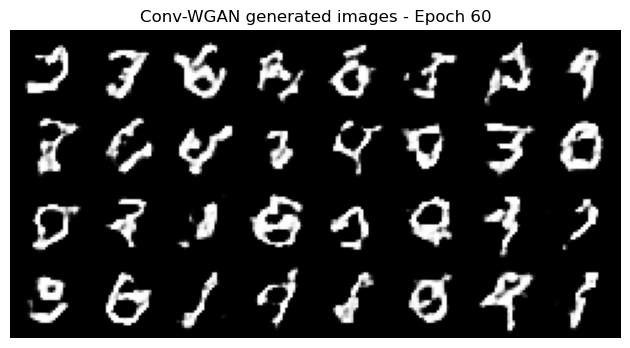

Epoch [65/200] C_loss: -1.5081 | G_loss: -92.1274 | W_est: 1.5081 | C(real): 93.6392 | C(fake): 92.1311
Epoch [70/200] C_loss: -1.2879 | G_loss: -92.7123 | W_est: 1.2879 | C(real): 94.0891 | C(fake): 92.8012
Epoch [75/200] C_loss: -1.1435 | G_loss: -91.2768 | W_est: 1.1435 | C(real): 92.5054 | C(fake): 91.3620
Epoch [80/200] C_loss: -1.0371 | G_loss: -89.5278 | W_est: 1.0371 | C(real): 90.6456 | C(fake): 89.6085


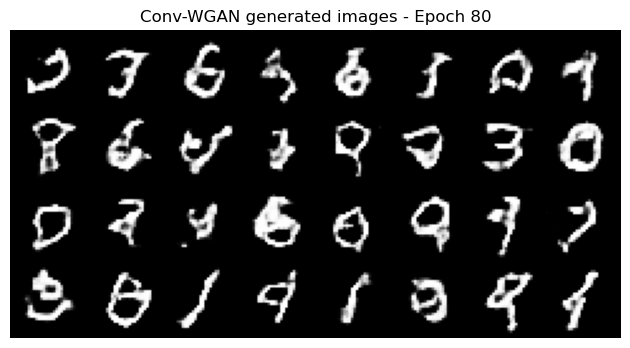

Epoch [85/200] C_loss: -0.9500 | G_loss: -87.9735 | W_est: 0.9500 | C(real): 89.1487 | C(fake): 88.1987
Epoch [90/200] C_loss: -0.8748 | G_loss: -86.5546 | W_est: 0.8748 | C(real): 87.5761 | C(fake): 86.7013
Epoch [95/200] C_loss: -0.8004 | G_loss: -81.8355 | W_est: 0.8004 | C(real): 82.7550 | C(fake): 81.9546
Epoch [100/200] C_loss: -0.7578 | G_loss: -81.6755 | W_est: 0.7578 | C(real): 82.5252 | C(fake): 81.7675


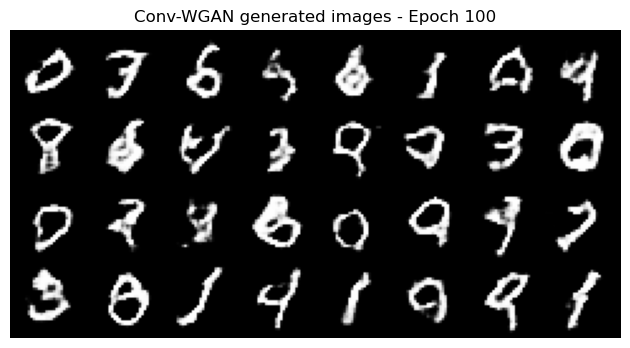

Epoch [105/200] C_loss: -0.7109 | G_loss: -78.4779 | W_est: 0.7109 | C(real): 79.4504 | C(fake): 78.7395
Epoch [110/200] C_loss: -0.7016 | G_loss: -78.2600 | W_est: 0.7016 | C(real): 79.0912 | C(fake): 78.3896
Epoch [115/200] C_loss: -0.7019 | G_loss: -76.5306 | W_est: 0.7019 | C(real): 77.2327 | C(fake): 76.5308
Epoch [120/200] C_loss: -0.6782 | G_loss: -75.3170 | W_est: 0.6782 | C(real): 76.2017 | C(fake): 75.5236


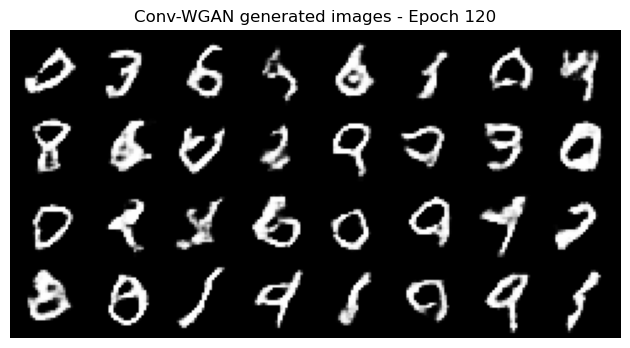

Epoch [125/200] C_loss: -0.6845 | G_loss: -76.5484 | W_est: 0.6845 | C(real): 77.1669 | C(fake): 76.4825
Epoch [130/200] C_loss: -0.6852 | G_loss: -75.8550 | W_est: 0.6852 | C(real): 76.6452 | C(fake): 75.9599
Epoch [135/200] C_loss: -0.6749 | G_loss: -76.5226 | W_est: 0.6749 | C(real): 77.0721 | C(fake): 76.3972
Epoch [140/200] C_loss: -0.6662 | G_loss: -73.5983 | W_est: 0.6662 | C(real): 74.3201 | C(fake): 73.6539


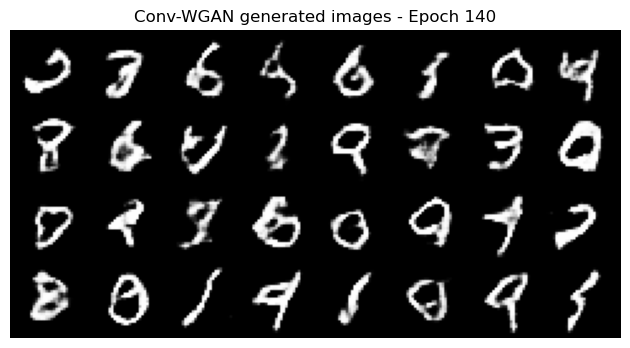

Epoch [145/200] C_loss: -0.6725 | G_loss: -74.9202 | W_est: 0.6725 | C(real): 75.7494 | C(fake): 75.0769
Epoch [150/200] C_loss: -0.6905 | G_loss: -74.2954 | W_est: 0.6905 | C(real): 74.9564 | C(fake): 74.2659
Epoch [155/200] C_loss: -0.6822 | G_loss: -74.6117 | W_est: 0.6822 | C(real): 75.4687 | C(fake): 74.7865
Epoch [160/200] C_loss: -0.6795 | G_loss: -74.9089 | W_est: 0.6795 | C(real): 75.7634 | C(fake): 75.0838


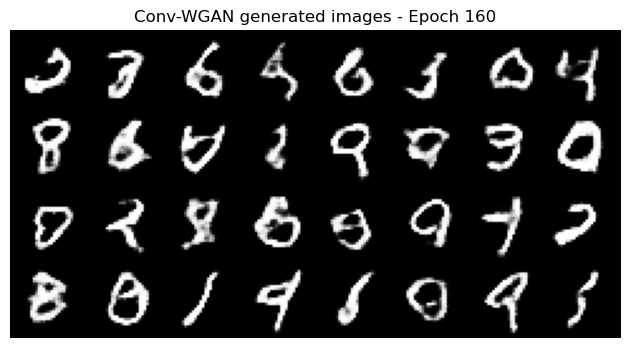

Epoch [165/200] C_loss: -0.6873 | G_loss: -74.4489 | W_est: 0.6873 | C(real): 75.2510 | C(fake): 74.5637
Epoch [170/200] C_loss: -0.6868 | G_loss: -74.9227 | W_est: 0.6868 | C(real): 75.4881 | C(fake): 74.8013
Epoch [175/200] C_loss: -0.6762 | G_loss: -71.8894 | W_est: 0.6762 | C(real): 72.8715 | C(fake): 72.1953
Epoch [180/200] C_loss: -0.6656 | G_loss: -72.9636 | W_est: 0.6656 | C(real): 73.8625 | C(fake): 73.1969


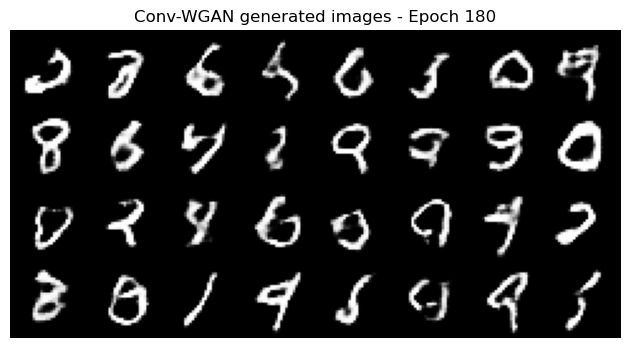

Epoch [185/200] C_loss: -0.6737 | G_loss: -73.7761 | W_est: 0.6737 | C(real): 74.3699 | C(fake): 73.6962
Epoch [190/200] C_loss: -0.6766 | G_loss: -74.7610 | W_est: 0.6766 | C(real): 75.5721 | C(fake): 74.8955
Epoch [195/200] C_loss: -0.6549 | G_loss: -73.4426 | W_est: 0.6549 | C(real): 74.2117 | C(fake): 73.5568
Epoch [200/200] C_loss: -0.6538 | G_loss: -72.6040 | W_est: 0.6538 | C(real): 73.4575 | C(fake): 72.8037


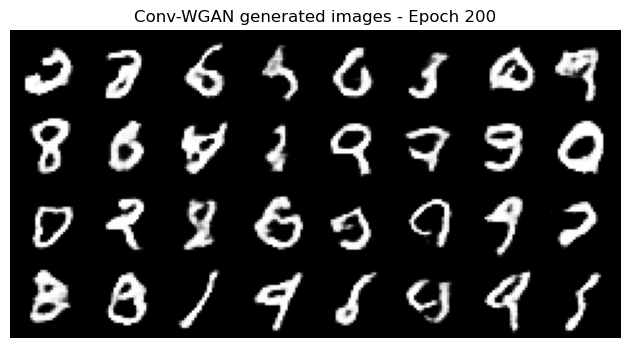

WGAN training time: 1330.24 seconds


In [43]:
EPOCHS_WGAN = 200
N_CRITIC_WGAN = 5
CLIP_VALUE = 0.05
LR_WGAN = 5e-5

wgan_generator = Generator(LATENT_DIM).to(device)
wgan_critic = Critic().to(device)
wgan_generator.apply(initialize_weights)
wgan_critic.apply(initialize_weights)

optimizer_G = optim.RMSprop(wgan_generator.parameters(), lr=LR_WGAN)
optimizer_C = optim.RMSprop(wgan_critic.parameters(), lr=LR_WGAN)

fixed_noise = torch.randn(32, LATENT_DIM, device=device)

history_wgan = {
    "critic_loss": [],
    "generator_loss": [],
    "wasserstein_estimate": [],
    "real_score": [],
    "fake_score": []
}

critic_updates = 0
start_time = time.time()

for epoch in range(1, EPOCHS_WGAN + 1):
    wgan_generator.train()
    wgan_critic.train()

    epoch_c_loss = []
    epoch_g_loss = []
    epoch_w_est = []
    epoch_real_score = []
    epoch_fake_score = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # -------------------------
        # 1. Train critic
        # -------------------------
        set_requires_grad(wgan_critic, True)
        set_requires_grad(wgan_generator, False)

        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = wgan_generator(z).detach()

        real_scores = wgan_critic(real_images)
        fake_scores = wgan_critic(fake_images)

        c_loss = critic_loss_wgan(real_scores, fake_scores)

        optimizer_C.zero_grad(set_to_none=True)
        c_loss.backward()
        optimizer_C.step()

        # Weight clipping for the original WGAN Lipschitz constraint.
        for p in wgan_critic.parameters():
            p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

        critic_updates += 1

        wasserstein_estimate = real_scores.mean().item() - fake_scores.mean().item()

        epoch_c_loss.append(c_loss.item())
        epoch_w_est.append(wasserstein_estimate)
        epoch_real_score.append(real_scores.mean().item())
        epoch_fake_score.append(fake_scores.mean().item())

        # -------------------------
        # 2. Train generator every N_CRITIC_WGAN critic updates
        # -------------------------
        if critic_updates % N_CRITIC_WGAN == 0:
            set_requires_grad(wgan_critic, False)
            set_requires_grad(wgan_generator, True)

            z = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_images = wgan_generator(z)
            fake_scores_for_g = wgan_critic(fake_images)
            g_loss = generator_loss_wgan(fake_scores_for_g)

            optimizer_G.zero_grad(set_to_none=True)
            g_loss.backward()
            optimizer_G.step()

            epoch_g_loss.append(g_loss.item())

    set_requires_grad(wgan_critic, True)
    set_requires_grad(wgan_generator, True)

    mean_c_loss = float(np.mean(epoch_c_loss))
    mean_g_loss = float(np.mean(epoch_g_loss)) if epoch_g_loss else float("nan")
    mean_w_est = float(np.mean(epoch_w_est))
    mean_real_score = float(np.mean(epoch_real_score))
    mean_fake_score = float(np.mean(epoch_fake_score))

    history_wgan["critic_loss"].append(mean_c_loss)
    history_wgan["generator_loss"].append(mean_g_loss)
    history_wgan["wasserstein_estimate"].append(mean_w_est)
    history_wgan["real_score"].append(mean_real_score)
    history_wgan["fake_score"].append(mean_fake_score)
    if critic_updates % N_CRITIC_WGAN == 0:
        print(
            f"Epoch [{epoch}/{EPOCHS_WGAN}] "
            f"C_loss: {mean_c_loss:.4f} | "
            f"G_loss: {mean_g_loss:.4f} | "
            f"W_est: {mean_w_est:.4f} | "
            f"C(real): {mean_real_score:.4f} | "
            f"C(fake): {mean_fake_score:.4f}"
        )

    if epoch % int(EPOCHS_WGAN / 10) == 0 and epoch != 0:
        wgan_generator.eval()
        with torch.no_grad():
            samples = wgan_generator(fixed_noise)
        show_images(samples, title=f"Conv-WGAN generated images - Epoch {epoch}")

print("WGAN training time:", round(time.time() - start_time, 2), "seconds")


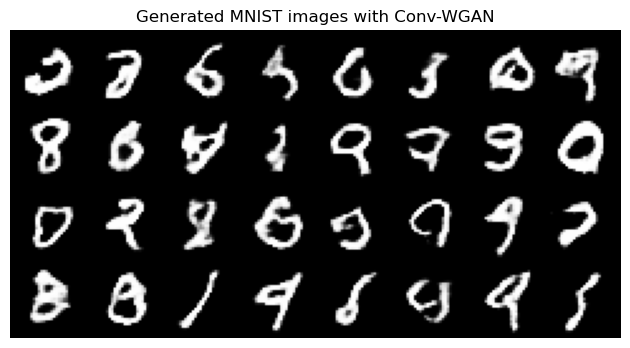

In [44]:
## 6. Generate images

def generate_images(generator, noise=None, n_images=32):
    generator.eval()
    with torch.no_grad():
        if noise is None:
            noise = torch.randn(n_images, LATENT_DIM, device=device)
        fake_images = generator(noise.to(device))
    return fake_images


wgan_samples = generate_images(wgan_generator, fixed_noise, n_images=32)
show_images(wgan_samples, title="Generated MNIST images with Conv-WGAN", nrow=8, figsize=(8, 4))


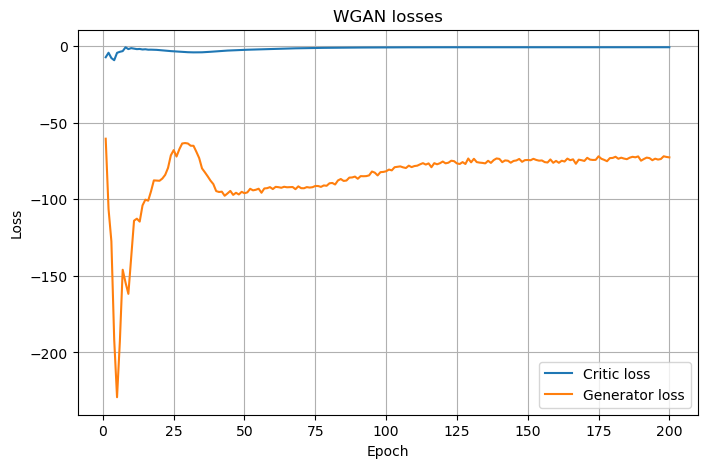

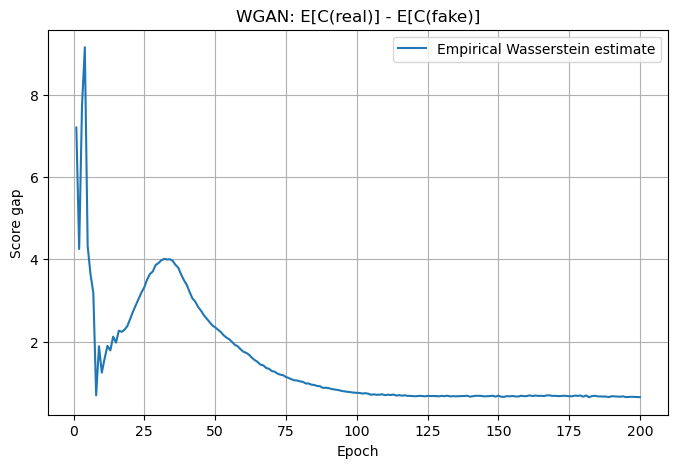

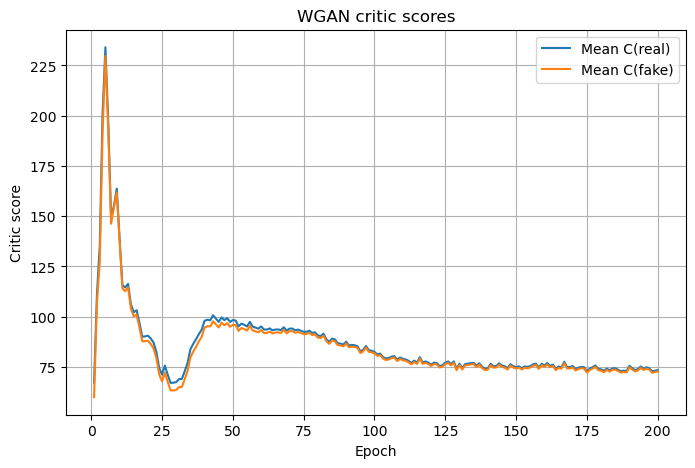

In [45]:
## 7. Training curves and Wasserstein estimate

def plot_history(history, title_prefix="WGAN"):
    epochs = range(1, len(history["critic_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["critic_loss"], label="Critic loss")
    plt.plot(epochs, history["generator_loss"], label="Generator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} losses")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["wasserstein_estimate"], label="Empirical Wasserstein estimate")
    plt.xlabel("Epoch")
    plt.ylabel("Score gap")
    plt.title(f"{title_prefix}: E[C(real)] - E[C(fake)]")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["real_score"], label="Mean C(real)")
    plt.plot(epochs, history["fake_score"], label="Mean C(fake)")
    plt.xlabel("Epoch")
    plt.ylabel("Critic score")
    plt.title(f"{title_prefix} critic scores")
    plt.legend()
    plt.grid(True)
    plt.show()

    if "gradient_penalty" in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history["gradient_penalty"], label="Gradient penalty")
        plt.xlabel("Epoch")
        plt.ylabel("GP")
        plt.title(f"{title_prefix} gradient penalty")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_history(history_wgan, title_prefix="WGAN")


## 8. Convolutional WGAN-GP

Weight clipping is simple but crude. It can reduce the capacity of the critic and lead to poor gradients for the generator.

WGAN-GP replaces clipping with a **gradient penalty**:

$$
\lambda \mathbb{E}_{\hat{x}}
\left[
\left(\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1\right)^2
\right],
$$

where $\hat{x}$ is sampled on straight lines between real and fake images:

$$
\hat{x} = \epsilon x_{\text{real}} + (1-\epsilon)x_{\text{fake}}.
$$

The critic loss becomes:

$$
L_C
=
\mathbb{E}[C(x_{\text{fake}})]
-
\mathbb{E}[C(x_{\text{real}})]
+
\lambda GP.
$$

No weight clipping is used in WGAN-GP.


In [46]:
def gradient_penalty(critic, real_images, fake_images, device):
    batch_size = real_images.size(0)

    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real_images + (1 - alpha) * fake_images.detach()
    interpolated.requires_grad_(True)

    interpolated_scores = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=interpolated_scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(interpolated_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.reshape(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    penalty = ((gradient_norm - 1) ** 2).mean()

    return penalty


Epoch [5/200] C_loss: -0.3893 | G_loss: -20.5586 | W_est: 0.4135 | GP: 0.0024 | C(real): 21.0422 | C(fake): 20.6287
Epoch [10/200] C_loss: -0.4601 | G_loss: -18.3973 | W_est: 0.4670 | GP: 0.0007 | C(real): 18.9261 | C(fake): 18.4591
Epoch [15/200] C_loss: -1.7130 | G_loss: -0.5439 | W_est: 1.7931 | GP: 0.0080 | C(real): 2.3887 | C(fake): 0.5957
Epoch [20/200] C_loss: -1.6160 | G_loss: -6.1121 | W_est: 1.7584 | GP: 0.0142 | C(real): 7.8676 | C(fake): 6.1091


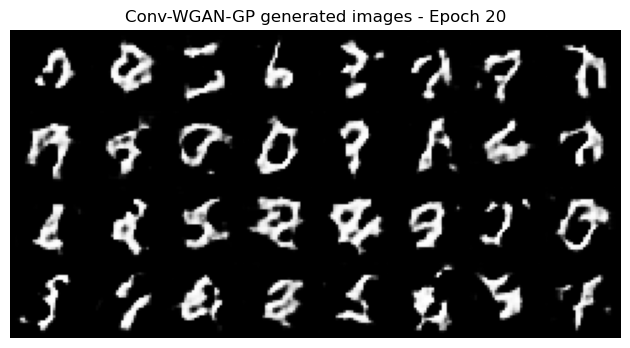

Epoch [25/200] C_loss: -1.3869 | G_loss: -8.0755 | W_est: 1.5081 | GP: 0.0121 | C(real): 9.7218 | C(fake): 8.2137
Epoch [30/200] C_loss: -1.0629 | G_loss: -12.6157 | W_est: 1.1528 | GP: 0.0090 | C(real): 13.7959 | C(fake): 12.6431
Epoch [35/200] C_loss: -0.8562 | G_loss: -16.8267 | W_est: 0.9247 | GP: 0.0069 | C(real): 17.9113 | C(fake): 16.9866
Epoch [40/200] C_loss: -0.7407 | G_loss: -19.8963 | W_est: 0.8000 | GP: 0.0059 | C(real): 20.7693 | C(fake): 19.9693


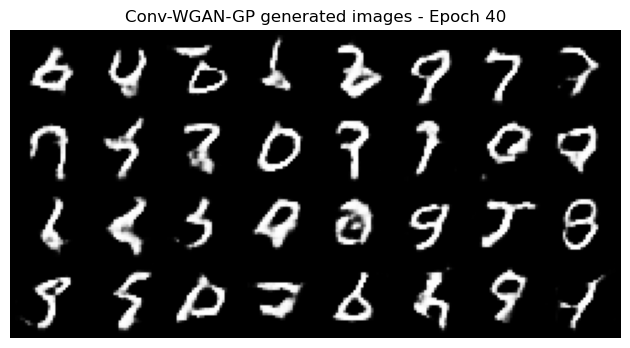

Epoch [45/200] C_loss: -0.7321 | G_loss: -20.4242 | W_est: 0.7913 | GP: 0.0059 | C(real): 21.2208 | C(fake): 20.4295
Epoch [50/200] C_loss: -0.7478 | G_loss: -21.3230 | W_est: 0.8061 | GP: 0.0058 | C(real): 22.2204 | C(fake): 21.4142
Epoch [55/200] C_loss: -0.7773 | G_loss: -21.4557 | W_est: 0.8340 | GP: 0.0057 | C(real): 22.2537 | C(fake): 21.4197
Epoch [60/200] C_loss: -0.7975 | G_loss: -21.6705 | W_est: 0.8594 | GP: 0.0062 | C(real): 22.5428 | C(fake): 21.6834


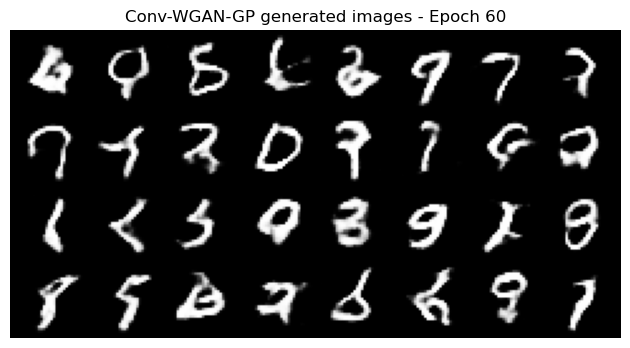

Epoch [65/200] C_loss: -0.7894 | G_loss: -21.2353 | W_est: 0.8476 | GP: 0.0058 | C(real): 22.2332 | C(fake): 21.3856
Epoch [70/200] C_loss: -0.7846 | G_loss: -21.2006 | W_est: 0.8437 | GP: 0.0059 | C(real): 22.0703 | C(fake): 21.2265
Epoch [75/200] C_loss: -0.7593 | G_loss: -20.1086 | W_est: 0.8165 | GP: 0.0057 | C(real): 20.9696 | C(fake): 20.1531
Epoch [80/200] C_loss: -0.7565 | G_loss: -18.9781 | W_est: 0.8132 | GP: 0.0057 | C(real): 19.8941 | C(fake): 19.0809


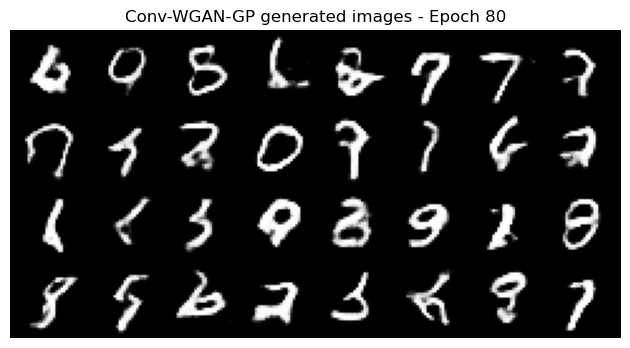

Epoch [85/200] C_loss: -0.7322 | G_loss: -18.3076 | W_est: 0.7875 | GP: 0.0055 | C(real): 19.1288 | C(fake): 18.3413
Epoch [90/200] C_loss: -0.7246 | G_loss: -17.3551 | W_est: 0.7808 | GP: 0.0056 | C(real): 18.1555 | C(fake): 17.3747
Epoch [95/200] C_loss: -0.6984 | G_loss: -16.7928 | W_est: 0.7535 | GP: 0.0055 | C(real): 17.6846 | C(fake): 16.9312
Epoch [100/200] C_loss: -0.6907 | G_loss: -16.4419 | W_est: 0.7440 | GP: 0.0053 | C(real): 17.2915 | C(fake): 16.5475


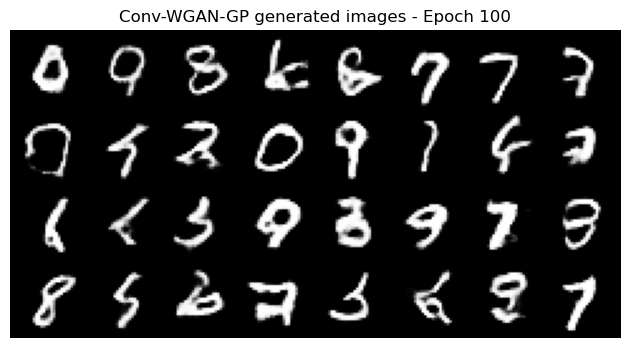

Epoch [105/200] C_loss: -0.6697 | G_loss: -16.2296 | W_est: 0.7236 | GP: 0.0054 | C(real): 17.0146 | C(fake): 16.2910
Epoch [110/200] C_loss: -0.6588 | G_loss: -15.6804 | W_est: 0.7118 | GP: 0.0053 | C(real): 16.4327 | C(fake): 15.7209
Epoch [115/200] C_loss: -0.6428 | G_loss: -15.1451 | W_est: 0.6945 | GP: 0.0052 | C(real): 15.9076 | C(fake): 15.2131
Epoch [120/200] C_loss: -0.6308 | G_loss: -14.5216 | W_est: 0.6823 | GP: 0.0051 | C(real): 15.2694 | C(fake): 14.5872


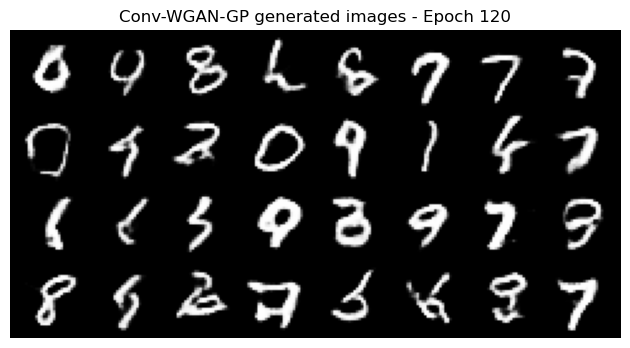

Epoch [125/200] C_loss: -0.6250 | G_loss: -14.2892 | W_est: 0.6750 | GP: 0.0050 | C(real): 15.0543 | C(fake): 14.3792
Epoch [130/200] C_loss: -0.6078 | G_loss: -13.7846 | W_est: 0.6587 | GP: 0.0051 | C(real): 14.4009 | C(fake): 13.7422
Epoch [135/200] C_loss: -0.6046 | G_loss: -13.7690 | W_est: 0.6555 | GP: 0.0051 | C(real): 14.4613 | C(fake): 13.8059
Epoch [140/200] C_loss: -0.5921 | G_loss: -13.4293 | W_est: 0.6423 | GP: 0.0050 | C(real): 14.0627 | C(fake): 13.4205


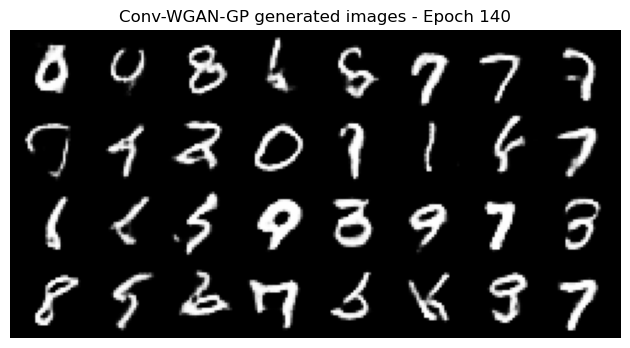

Epoch [145/200] C_loss: -0.5827 | G_loss: -13.0906 | W_est: 0.6325 | GP: 0.0050 | C(real): 13.7269 | C(fake): 13.0944
Epoch [150/200] C_loss: -0.5863 | G_loss: -12.6070 | W_est: 0.6380 | GP: 0.0052 | C(real): 13.3836 | C(fake): 12.7456
Epoch [155/200] C_loss: -0.5644 | G_loss: -12.5264 | W_est: 0.6136 | GP: 0.0049 | C(real): 13.1534 | C(fake): 12.5399
Epoch [160/200] C_loss: -0.5574 | G_loss: -12.1890 | W_est: 0.6055 | GP: 0.0048 | C(real): 12.8712 | C(fake): 12.2657


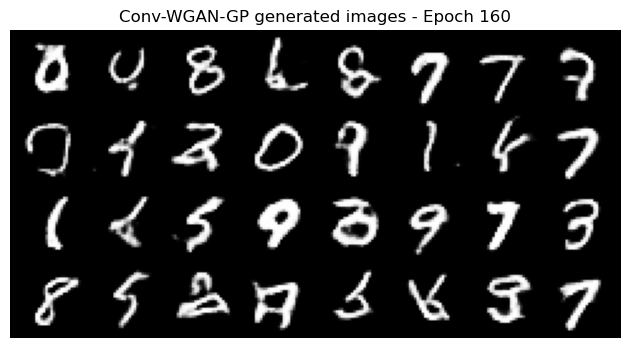

Epoch [165/200] C_loss: -0.5448 | G_loss: -11.9877 | W_est: 0.5922 | GP: 0.0047 | C(real): 12.6122 | C(fake): 12.0200
Epoch [170/200] C_loss: -0.5377 | G_loss: -11.6286 | W_est: 0.5839 | GP: 0.0046 | C(real): 12.2373 | C(fake): 11.6534
Epoch [175/200] C_loss: -0.5258 | G_loss: -11.8073 | W_est: 0.5729 | GP: 0.0047 | C(real): 12.3326 | C(fake): 11.7596
Epoch [180/200] C_loss: -0.5264 | G_loss: -11.2913 | W_est: 0.5717 | GP: 0.0045 | C(real): 11.9247 | C(fake): 11.3530


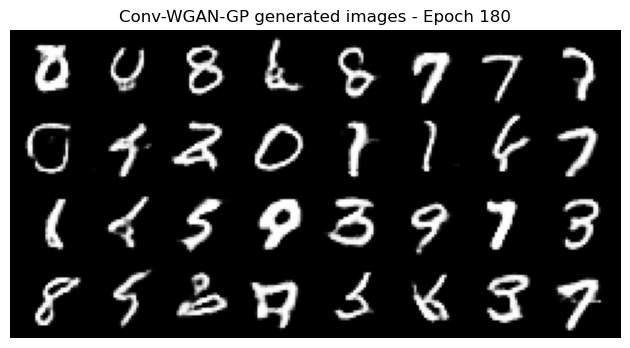

Epoch [185/200] C_loss: -0.5190 | G_loss: -10.9438 | W_est: 0.5648 | GP: 0.0046 | C(real): 11.5065 | C(fake): 10.9416
Epoch [190/200] C_loss: -0.5032 | G_loss: -10.5280 | W_est: 0.5491 | GP: 0.0046 | C(real): 11.1886 | C(fake): 10.6395
Epoch [195/200] C_loss: -0.4977 | G_loss: -10.4011 | W_est: 0.5420 | GP: 0.0044 | C(real): 10.9409 | C(fake): 10.3990
Epoch [200/200] C_loss: -0.4935 | G_loss: -10.4375 | W_est: 0.5375 | GP: 0.0044 | C(real): 11.1279 | C(fake): 10.5904


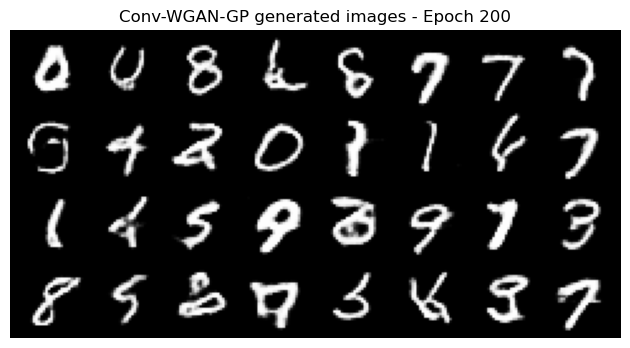

WGAN-GP training time: 1414.96 seconds


In [47]:
EPOCHS_GP = 200
N_CRITIC_GP = 5
LAMBDA_GP = 10
LR_G_GP = 1e-4
LR_C_GP = 5e-5

wgan_gp_generator = Generator(LATENT_DIM).to(device)
wgan_gp_critic = Critic().to(device)
wgan_gp_generator.apply(initialize_weights)
wgan_gp_critic.apply(initialize_weights)

optimizer_G = optim.Adam(wgan_gp_generator.parameters(), lr=LR_G_GP, betas=(0.0, 0.9))
optimizer_C = optim.Adam(wgan_gp_critic.parameters(), lr=LR_C_GP, betas=(0.0, 0.9))

fixed_noise_gp = torch.randn(32, LATENT_DIM, device=device)

history_gp = {
    "critic_loss": [],
    "generator_loss": [],
    "wasserstein_estimate": [],
    "gradient_penalty": [],
    "real_score": [],
    "fake_score": []
}

critic_updates = 0
start_time = time.time()

for epoch in range(1, EPOCHS_GP + 1):
    wgan_gp_generator.train()
    wgan_gp_critic.train()

    epoch_c_loss = []
    epoch_g_loss = []
    epoch_w_est = []
    epoch_gp = []
    epoch_real_score = []
    epoch_fake_score = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # -------------------------
        # 1. Train critic
        # -------------------------
        set_requires_grad(wgan_gp_critic, True)
        set_requires_grad(wgan_gp_generator, False)

        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = wgan_gp_generator(z).detach()

        real_scores = wgan_gp_critic(real_images)
        fake_scores = wgan_gp_critic(fake_images)

        gp = gradient_penalty(
            critic=wgan_gp_critic,
            real_images=real_images,
            fake_images=fake_images,
            device=device
        )

        c_loss = (
            fake_scores.mean()
            - real_scores.mean()
            + LAMBDA_GP * gp
        )

        optimizer_C.zero_grad(set_to_none=True)
        c_loss.backward()
        optimizer_C.step()

        # Important: no weight clipping in WGAN-GP.
        critic_updates += 1

        wasserstein_estimate = real_scores.mean().item() - fake_scores.mean().item()

        epoch_c_loss.append(c_loss.item())
        epoch_w_est.append(wasserstein_estimate)
        epoch_gp.append(gp.item())
        epoch_real_score.append(real_scores.mean().item())
        epoch_fake_score.append(fake_scores.mean().item())

        # -------------------------
        # 2. Train generator every N_CRITIC_GP critic updates
        # -------------------------
        if critic_updates % N_CRITIC_GP == 0:
            set_requires_grad(wgan_gp_critic, False)
            set_requires_grad(wgan_gp_generator, True)

            z = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_images = wgan_gp_generator(z)
            fake_scores_for_g = wgan_gp_critic(fake_images)
            g_loss = generator_loss_wgan(fake_scores_for_g)

            optimizer_G.zero_grad(set_to_none=True)
            g_loss.backward()
            optimizer_G.step()

            epoch_g_loss.append(g_loss.item())

    set_requires_grad(wgan_gp_critic, True)
    set_requires_grad(wgan_gp_generator, True)

    mean_c_loss = float(np.mean(epoch_c_loss))
    mean_g_loss = float(np.mean(epoch_g_loss)) if epoch_g_loss else float("nan")
    mean_w_est = float(np.mean(epoch_w_est))
    mean_gp = float(np.mean(epoch_gp))
    mean_real_score = float(np.mean(epoch_real_score))
    mean_fake_score = float(np.mean(epoch_fake_score))

    history_gp["critic_loss"].append(mean_c_loss)
    history_gp["generator_loss"].append(mean_g_loss)
    history_gp["wasserstein_estimate"].append(mean_w_est)
    history_gp["gradient_penalty"].append(mean_gp)
    history_gp["real_score"].append(mean_real_score)
    history_gp["fake_score"].append(mean_fake_score)

    if critic_updates % N_CRITIC_GP == 0:
        print(
            f"Epoch [{epoch}/{EPOCHS_GP}] "
            f"C_loss: {mean_c_loss:.4f} | "
            f"G_loss: {mean_g_loss:.4f} | "
            f"W_est: {mean_w_est:.4f} | "
            f"GP: {mean_gp:.4f} | "
            f"C(real): {mean_real_score:.4f} | "
            f"C(fake): {mean_fake_score:.4f}"
        )

    if epoch % int(EPOCHS_GP / 10) == 0 and epoch != 0:
        wgan_gp_generator.eval()
        with torch.no_grad():
            samples = wgan_gp_generator(fixed_noise_gp)
        show_images(samples, title=f"Conv-WGAN-GP generated images - Epoch {epoch}")

print("WGAN-GP training time:", round(time.time() - start_time, 2), "seconds")


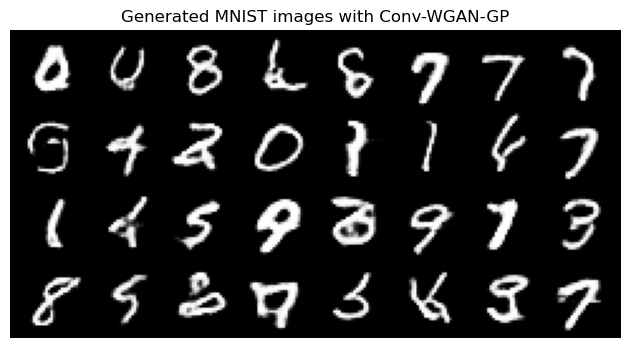

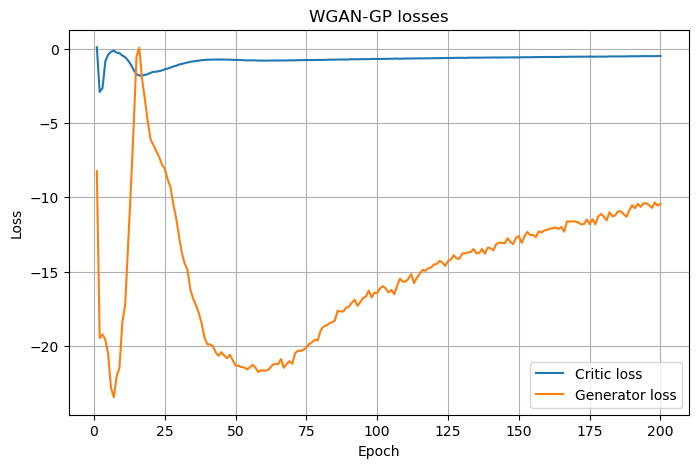

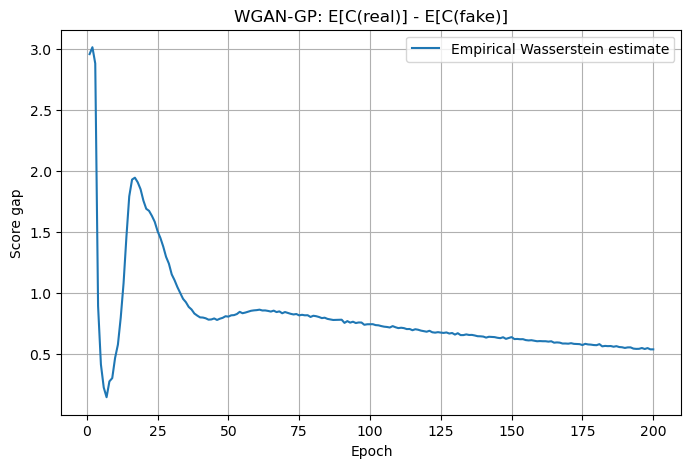

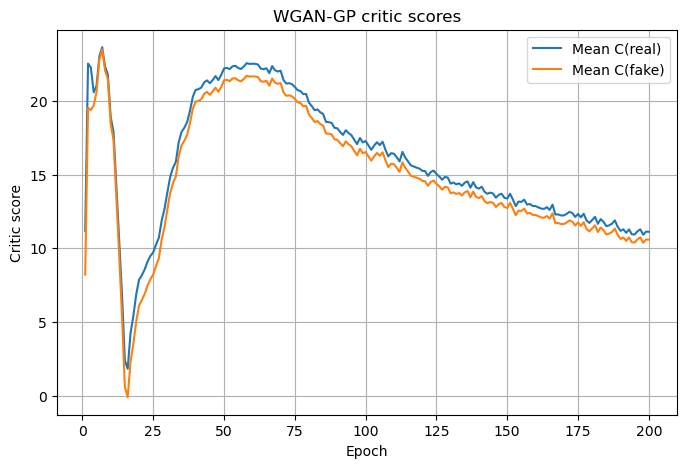

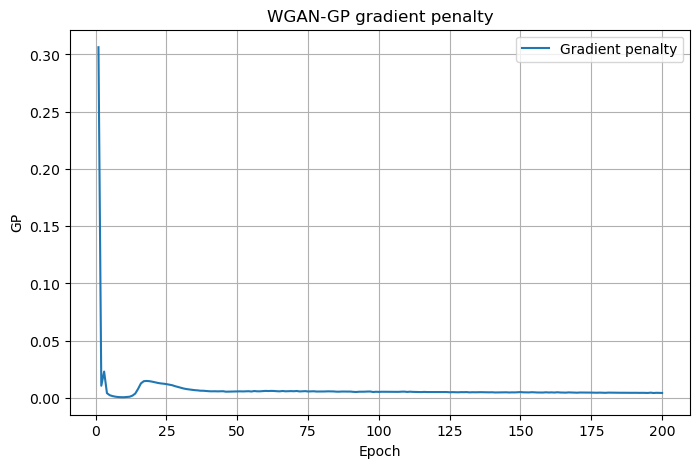

In [48]:
wgan_gp_samples = generate_images(wgan_gp_generator, fixed_noise_gp, n_images=32)
show_images(wgan_gp_samples, title="Generated MNIST images with Conv-WGAN-GP", nrow=8, figsize=(8, 4))
plot_history(history_gp, title_prefix="WGAN-GP")

Conclusion to write: explain why the Lipschitz constraint is central to WGAN training and compare weight clipping with gradient penalty.

In WGAN, the Lipschitz constraint is central because the critic is used to approximate the Wasserstein distance between the real data distribution and the generated data distribution. According to the Kantorovich-Rubinstein duality, this approximation is valid only if the critic is a **1-Lipschitz function**. Therefore, enforcing the Lipschitz constraint ensures that the critic provides a meaningful and stable learning signal for the generator.

Weight clipping is a simple way to enforce this constraint: after each critic update, all critic weights are forced to stay within a fixed interval, such as $[-c, c]$. However, this method is quite crude. If the clipping range is too small, the critic may lose too much capacity and underfit. If it is too large, the Lipschitz constraint may not be properly enforced. As a result, training can become unstable or the critic can learn poor gradients.

Gradient penalty is a more flexible and effective alternative. Instead of directly clipping the weights, it penalizes the critic when the norm of its gradient with respect to the input deviates from 1. This encourages the critic to satisfy the Lipschitz constraint more smoothly. In practice, WGAN-GP usually provides more stable training, better gradients for the generator, and better sample quality than weight clipping.